In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
!ls /content

online_retail_II.csv  sample_data


Dataset Description

In [3]:
import pandas as pd

df = pd.read_csv('/content/online_retail_II.csv')

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(455999, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455999 entries, 0 to 455998
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      455999 non-null  object 
 1   StockCode    455999 non-null  object 
 2   Description  454621 non-null  object 
 3   Quantity     455999 non-null  int64  
 4   InvoiceDate  455999 non-null  object 
 5   Price        455999 non-null  float64
 6   Customer ID  343588 non-null  float64
 7   Country      455999 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.8+ MB


In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
df.describe()

,Quantity,Price,Customer ID
count,455999.000000,455999.000000,343588.000000
mean,9.786041,4.685826,15283.726187
std,165.011902,99.889572,1711.124335
min,-74215.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13925.000000
50%,3.000000,2.080000,15157.000000
75%,11.000000,4.130000,16779.000000
max,74215.000000,38970.000000,18287.000000


In [9]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1378
Quantity,0
InvoiceDate,0
Price,0
Customer ID,112411
Country,0


In [10]:
df.duplicated().sum()

np.int64(3998)

In [11]:
df.rename(columns={'Price':'UnitPrice'}, inplace=True)

 Data Cleaning

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Customer ID,0
Country,0


In [14]:
df.duplicated().sum()

np.int64(3957)

In [15]:
df.drop_duplicates(inplace=True)

Feature Engineering

In [16]:
df = df[df['Quantity'] > 0]

In [17]:
df = df[df['UnitPrice'] > 0]

In [18]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [20]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day

In [21]:
df.shape

(331721, 12)

 Exploratory Data Analysis

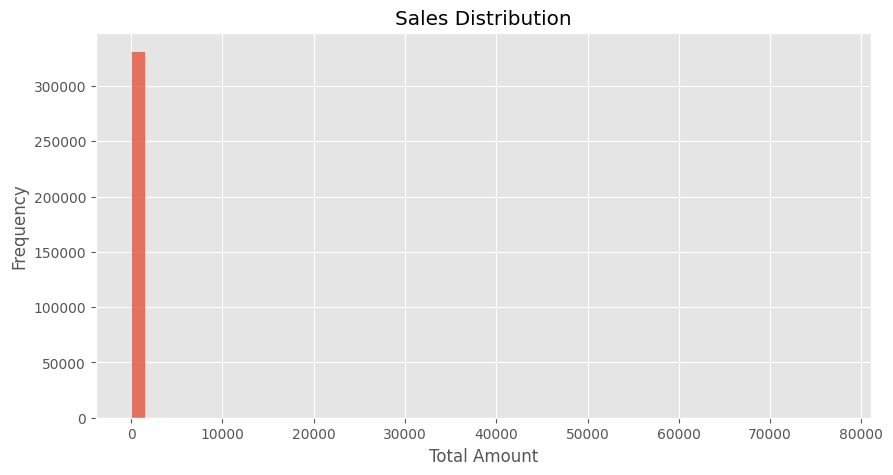

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df['TotalAmount'], bins=50)

plt.title("Sales Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

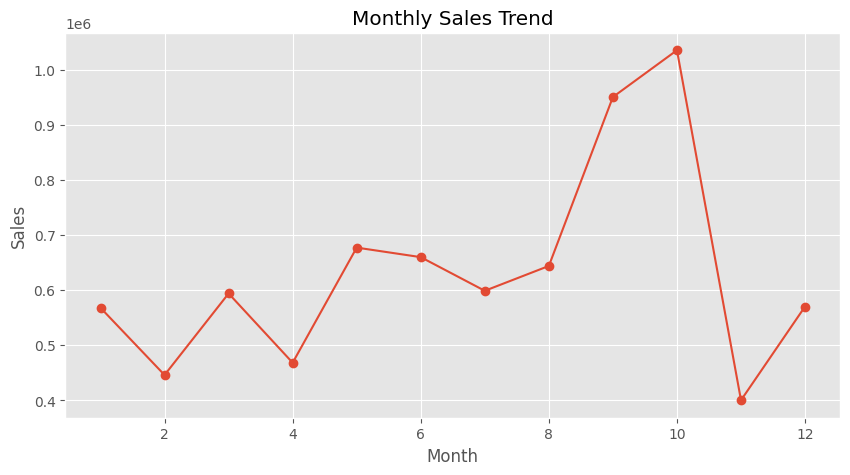

In [23]:
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

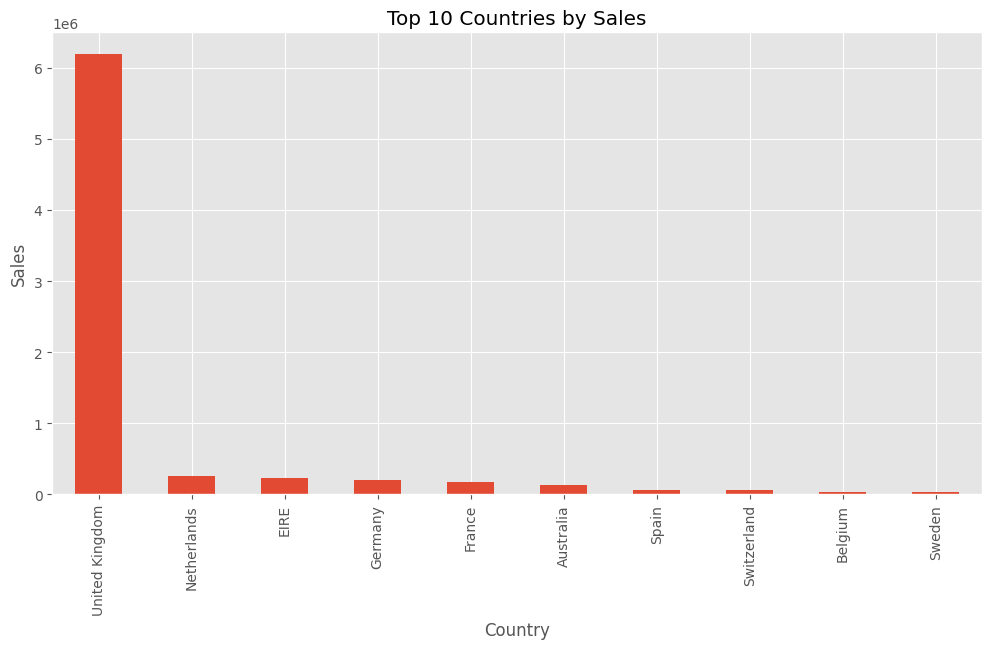

In [24]:
top_countries = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.show()

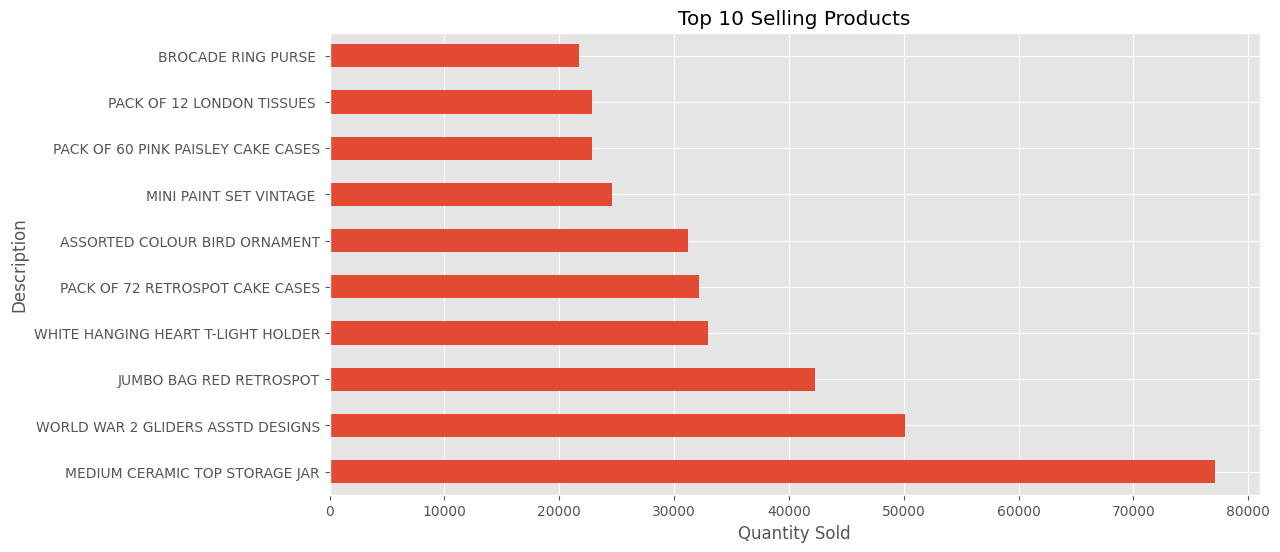

In [25]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='barh')

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")

plt.show()

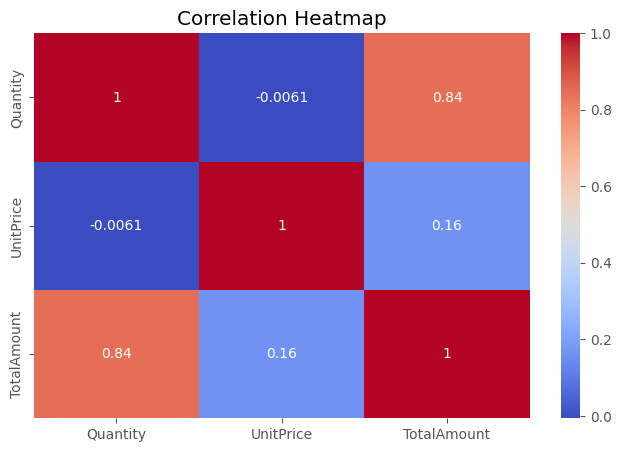

In [26]:
corr = df[['Quantity','UnitPrice','TotalAmount']].corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

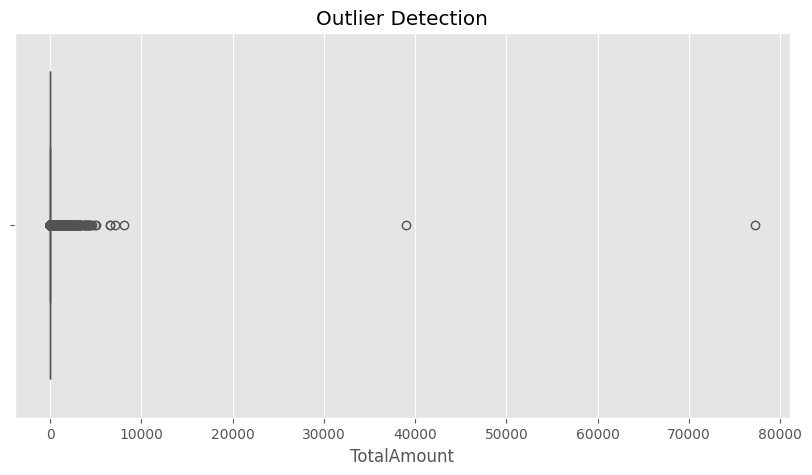

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalAmount'])

plt.title("Outlier Detection")

plt.show()

Customer Segmentation

In [28]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [29]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'count',
    'TotalAmount': 'sum'
})

In [30]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [31]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,297,1,77183.60
12347.0,11,171,4085.18
12348.0,47,31,1797.24
12350.0,281,17,334.40
12352.0,8,85,2506.04


In [32]:
rfm.describe()

,Recency,Frequency,Monetary
count,4095.000000,4095.000000,4095.000000
mean,92.759951,81.006349,1859.373832
std,95.797625,186.614516,8087.960789
min,1.000000,1.000000,2.900000
25%,18.000000,16.000000,294.620000
50%,49.000000,37.000000,636.140000
75%,150.000000,89.000000,1538.865000
max,345.000000,6272.000000,257249.820000


In [33]:
rfm.describe()

,Recency,Frequency,Monetary
count,4095.000000,4095.000000,4095.000000
mean,92.759951,81.006349,1859.373832
std,95.797625,186.614516,8087.960789
min,1.000000,1.000000,2.900000
25%,18.000000,16.000000,294.620000
50%,49.000000,37.000000,636.140000
75%,150.000000,89.000000,1538.865000
max,345.000000,6272.000000,257249.820000


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,297,1,77183.60,0
12347.0,11,171,4085.18,1
12348.0,47,31,1797.24,1
12350.0,281,17,334.40,0
12352.0,8,85,2506.04,1


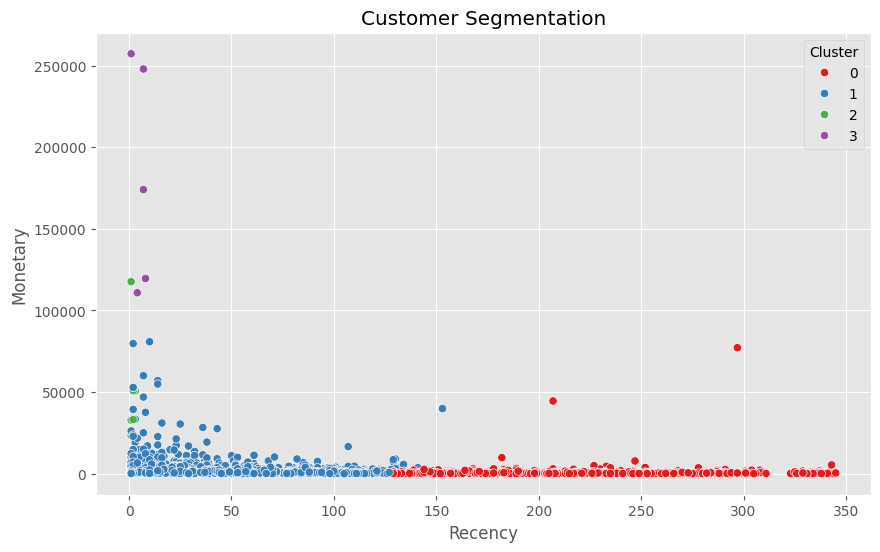

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set1'
)

plt.title("Customer Segmentation")

plt.show()

Demand Forecasting

In [38]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum()

In [39]:
daily_sales = daily_sales.reset_index()

In [40]:
daily_sales.columns = ['ds', 'y']

In [41]:
daily_sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


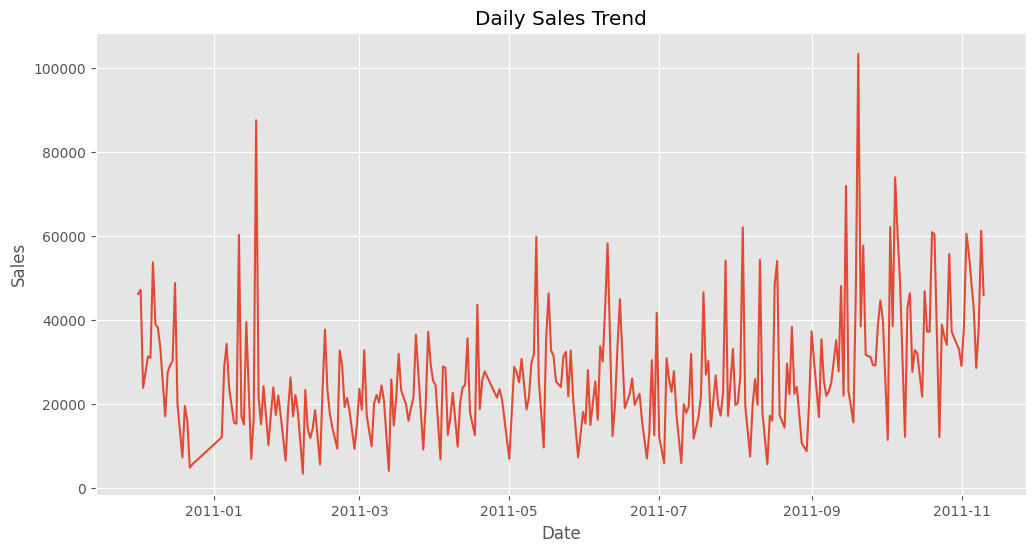

In [42]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [43]:
!pip install prophet

In [44]:
from prophet import Prophet

In [45]:
model = Prophet()

model.fit(daily_sales)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [46]:
future = model.make_future_dataframe(periods=30)

In [47]:
forecast = model.predict(future)

In [48]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
305,2011-12-06,47853.841567,33316.200782,63122.635747
306,2011-12-07,44252.554208,28527.796058,58653.326877
307,2011-12-08,52608.303793,37598.025507,67213.876769
308,2011-12-09,42458.233216,28187.385275,58887.115156
309,2011-12-10,56357.472253,41028.582509,71378.275601


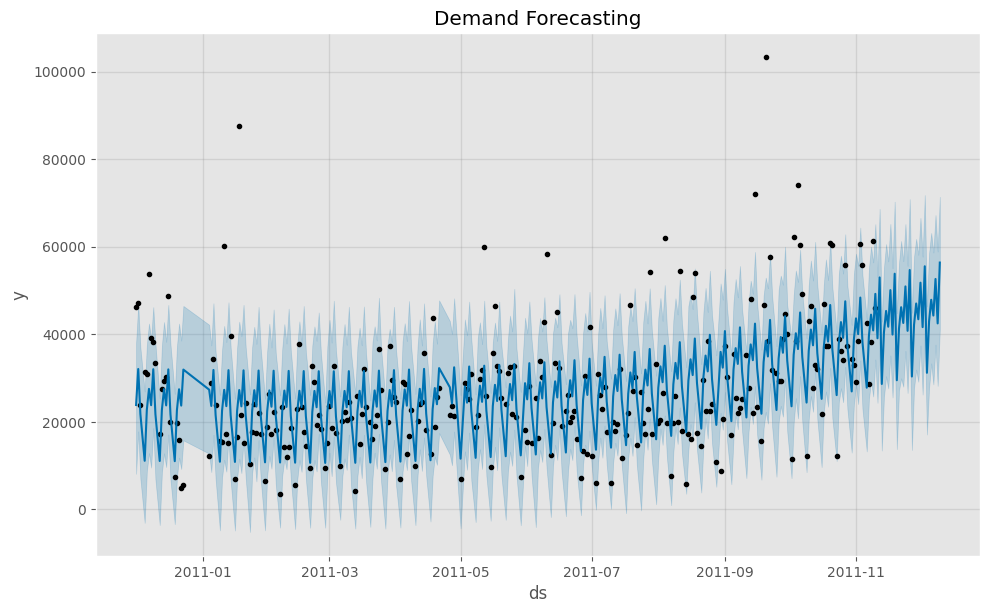

In [49]:
model.plot(forecast)

plt.title("Demand Forecasting")

plt.show()

Churn Analysis

In [50]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [51]:
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()

In [52]:
churn = (snapshot_date - last_purchase).dt.days > 90

In [53]:
churn_df = churn.reset_index()

In [54]:
churn_df.columns = ['CustomerID', 'Churn']

In [55]:
churn_df.head()

,CustomerID,Churn
0,12346.0,True
1,12347.0,False
2,12348.0,False
3,12350.0,True
4,12352.0,False


In [56]:
churn_df['Churn'].value_counts()

,count
Churn,
False,2597
True,1498


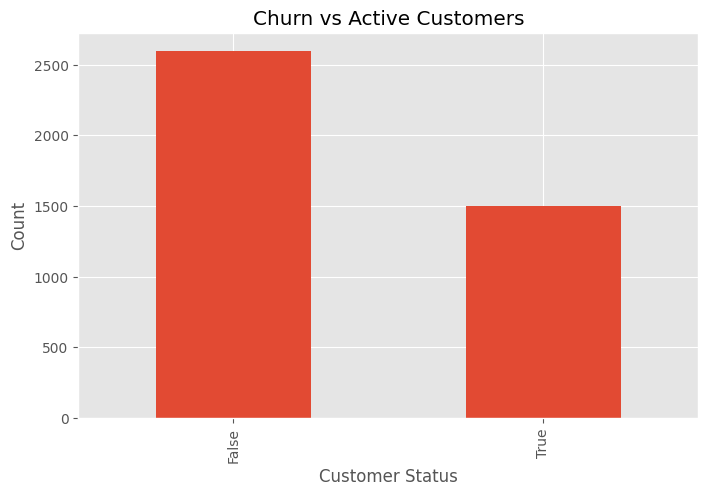

In [57]:
plt.figure(figsize=(8,5))

churn_df['Churn'].value_counts().plot(kind='bar')

plt.title("Churn vs Active Customers")
plt.xlabel("Customer Status")
plt.ylabel("Count")

plt.show()

Inventory Optimization

In [58]:
forecast[['ds','yhat']].tail()

,ds,yhat
305,2011-12-06,47853.841567
306,2011-12-07,44252.554208
307,2011-12-08,52608.303793
308,2011-12-09,42458.233216
309,2011-12-10,56357.472253


In [59]:
recommended_stock = forecast['yhat'].tail(30).sum()

In [60]:
print("Recommended Stock for Next 30 Days:", round(recommended_stock))

Recommended Stock for Next 30 Days: 1326913


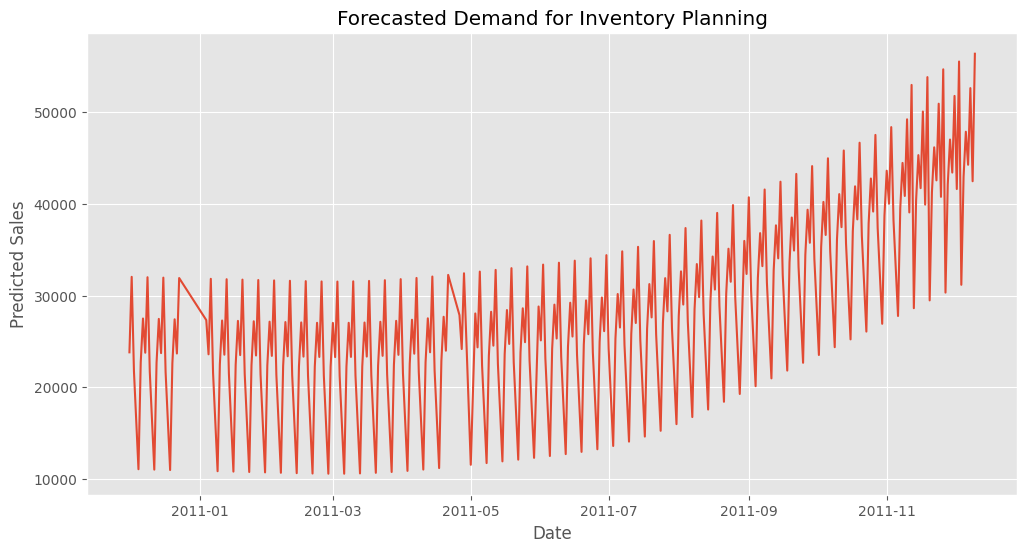

In [61]:
plt.figure(figsize=(12,6))

plt.plot(forecast['ds'], forecast['yhat'])

plt.title("Forecasted Demand for Inventory Planning")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.show()

 Conclusion

The RetailPulse project successfully analyzed retail transaction data using data science and machine learning techniques. Exploratory data analysis revealed important customer purchasing patterns and sales trends. Customer segmentation using RFM and KMeans identified different customer groups based on purchasing behavior. Demand forecasting using Prophet enabled future sales prediction, while churn analysis identified inactive customers. Inventory optimization techniques were also applied using forecasted demand values. Overall, the project demonstrates a complete end-to-end retail analytics workflow.

In [62]:
df.rename(columns={
    'Invoice':'InvoiceNo',
    'Customer ID':'CustomerID'
}, inplace=True)

In [63]:
df.to_csv('cleaned_retail_data.csv', index=False)

DB SCAN

In [64]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster,DBSCAN_Cluster
Customer ID,,,,,
12346.0,297,1,77183.60,0,-1
12347.0,11,171,4085.18,1,0
12348.0,47,31,1797.24,1,0
12350.0,281,17,334.40,0,0
12352.0,8,85,2506.04,1,0


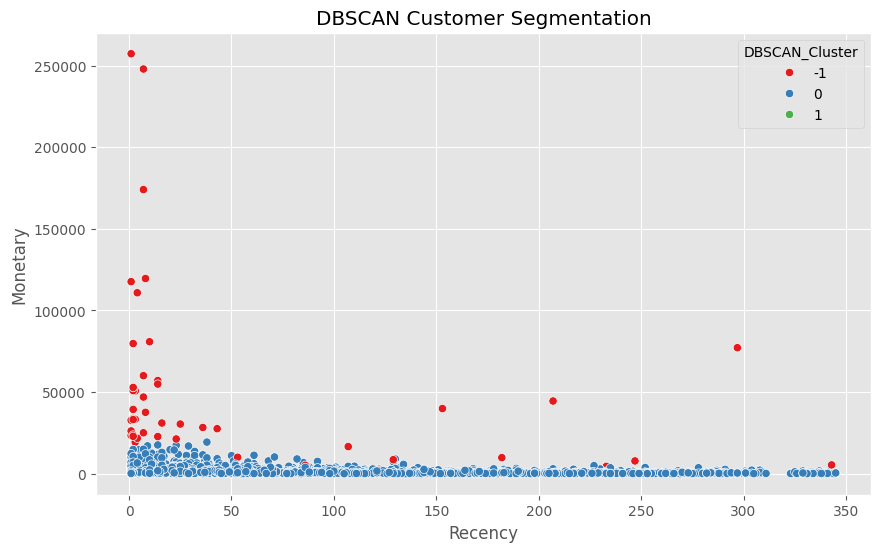

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    data=rfm,
    palette='Set1'
)

plt.title("DBSCAN Customer Segmentation")

plt.show()

DBSCAN clustering identified density-based customer groups and detected customer purchasing behavior patterns along with potential outliers.

Stationarity Test


In [66]:
!pip install statsmodels

In [67]:
from statsmodels.tsa.stattools import adfuller

In [68]:
sales_series = daily_sales['y']

In [69]:
result = adfuller(sales_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.5490177566626888
p-value: 0.5091388022440216


The Augmented Dickey-Fuller test was performed to analyze stationarity in the retail sales time-series data.

Time-Series Decomposition

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [71]:
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

daily_sales.set_index('ds', inplace=True)

In [72]:
decomposition = seasonal_decompose(daily_sales['y'], model='additive', period=30)

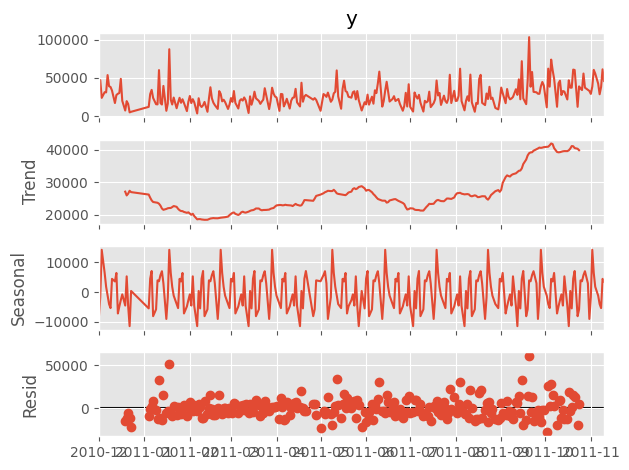

In [73]:
decomposition.plot()
plt.show()

The Augmented Dickey-Fuller test indicated that the retail sales time-series is non-stationary, as the p-value is greater than 0.05.

Churn prediction using XGBoost


In [74]:
!pip install xgboost

In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [76]:
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

In [77]:
X = rfm[['Recency','Frequency','Monetary']]

y = rfm['Churn']

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [79]:
model = XGBClassifier()

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
y_pred = model.predict(X_test)

In [81]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


The XGBoost model was trained to predict customer churn behavior using Recency, Frequency, and Monetary features.

<Figure size 800x500 with 0 Axes>

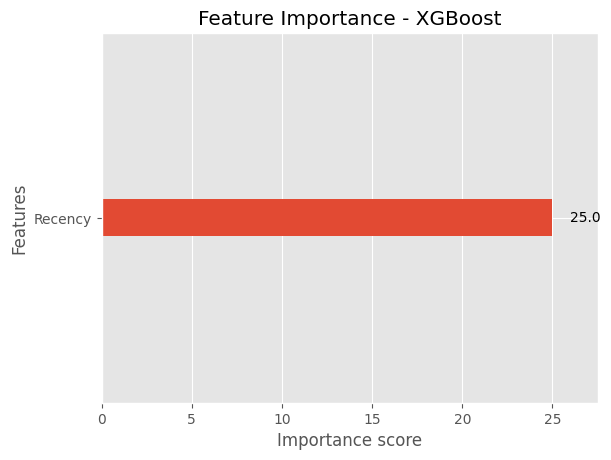

In [82]:
from xgboost import plot_importance

plt.figure(figsize=(8,5))

plot_importance(model)

plt.title("Feature Importance - XGBoost")

plt.show()

Feature importance analysis shows the contribution of Recency, Frequency, and Monetary features toward churn prediction.

Simple SHAP Explainability

In [83]:
!pip install shap

In [84]:
import shap

In [85]:
explainer = shap.Explainer(model)

In [86]:
shap_values = explainer(X_test)

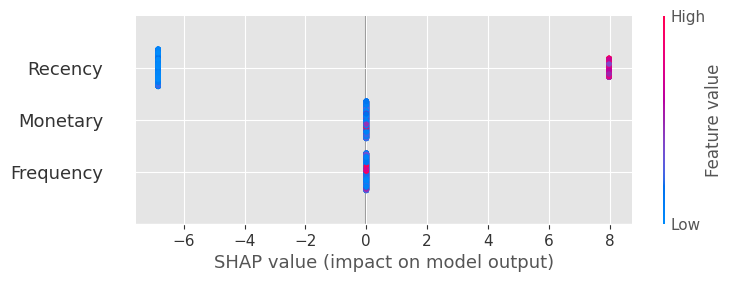

In [87]:
shap.plots.beeswarm(shap_values)

SHAP explainability analysis was used to interpret the impact of customer behavior features on churn prediction outcomes.

In [89]:
df.to_csv('cleaned_retail_data.csv', index=False)